#Bibliotecas

In [1]:
import os
import warnings
import itertools
import datetime as dt
import pandas as pd
import numpy as np
import random # Usado para random.sample e random.shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from scipy.stats import norm, skew, kurtosis, truncnorm, jarque_bera, shapiro # Importar diretamente as funções
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from scipy.optimize import curve_fit
from statsmodels.graphics.gofplots import qqplot
from multiprocessing import Pool
import random
import traceback # Importar para printar o traceback em caso de erro

# Importar nas classes quando usar função standalone

warnings.filterwarnings("ignore")

# Importando o Mercado Artificial

In [2]:
!rm -rf /content/Mercado-Artificial-Fiis
!git clone https://github.com/gilbertogilfgp/Mercado-Artificial-Fiis.git

import sys

if "msm" in sys.modules:
    del sys.modules["msm"]


caminho = "/content/Mercado-Artificial-Fiis/notebooks/funcoes"
if caminho not in sys.path:
    sys.path.append(caminho)


import msm

Cloning into 'Mercado-Artificial-Fiis'...
remote: Enumerating objects: 199, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 199 (delta 1), reused 0 (delta 0), pack-reused 193 (from 2)
Receiving objects: 100% (199/199), 12.72 MiB | 18.00 MiB/s, done.
Resolving deltas: 100% (100/100), done.


## Momentos do bootstrap

In [3]:
momentos_bootstrap_60 = pd.read_csv("/content/Mercado-Artificial-Fiis/notebooks/dados/momentos_bootstrap_60.csv")
momentos_bootstrap_60.head()

,Media,Variancia,Assimetria,Curtose,acf_5,acf_10,acf_15,acf_20,autocorr_q_1,autocorr_q_2
0,0.000118,0.000012,0.213727,4.515868,0.093849,-0.122388,-0.132560,-0.076454,0.273853,-0.061368
1,0.000119,0.000025,1.360185,10.886374,-0.082424,-0.089303,-0.015188,-0.090675,0.002511,0.193771
2,0.000625,0.000009,-0.042527,3.723290,-0.007000,-0.008742,-0.056362,0.000095,0.010856,0.244433
3,-0.000150,0.000005,0.302188,3.525203,-0.006252,-0.007793,-0.098288,-0.166206,0.077692,-0.093040
4,0.000295,0.000013,0.425409,4.184820,-0.152329,0.005074,-0.026395,-0.221523,0.355770,0.199653


In [4]:
# Calcular estatísticas por coluna
df_referencia_empirica_60 = pd.DataFrame({
    "Momento": momentos_bootstrap_60.columns,
    "Média do bootstrap": momentos_bootstrap_60.mean().values,
    "DP bootstrap": momentos_bootstrap_60.std().values,
    "IC 95% inf": momentos_bootstrap_60.quantile(0.025).values,
    "IC 95% sup": momentos_bootstrap_60.quantile(0.975).values,
})

df_referencia_empirica_60

,Momento,Média do bootstrap,DP bootstrap,IC 95% inf,IC 95% sup
0,Media,0.000052,0.000646,-0.001203,0.001351
1,Variancia,0.000014,0.000008,0.000005,0.000037
2,Assimetria,0.013964,0.913351,-1.784080,2.078316
3,Curtose,5.735955,2.810985,2.787951,12.936896
4,acf_5,-0.029352,0.119243,-0.274610,0.191849
5,acf_10,-0.021469,0.113322,-0.251494,0.210195
6,acf_15,-0.017443,0.111847,-0.234302,0.212489
7,acf_20,-0.023073,0.103335,-0.240387,0.167221
8,autocorr_q_1,0.204947,0.209008,-0.092942,0.671057
9,autocorr_q_2,0.080851,0.151514,-0.155613,0.396847


# Matriz de Pesos

In [5]:
lam = 1e-8
Cov_matrix_boot = momentos_bootstrap_60.cov()

# Regularização
Sigma_reg = Cov_matrix_boot.values + lam * np.eye(Cov_matrix_boot.shape[0])

W = np.linalg.inv(Sigma_reg)

pd.DataFrame(
    W,
    index=Cov_matrix_boot.index,
    columns=Cov_matrix_boot.columns
)

,Media,Variancia,Assimetria,Curtose,acf_5,acf_10,acf_15,acf_20,autocorr_q_1,autocorr_q_2
Media,3.046668e+06,1.037575e+05,-1021.310441,0.379224,882.234029,644.256289,353.438264,61.960399,-123.920320,709.430504
Variancia,1.037575e+05,9.968938e+07,-177.181364,-120.439607,225.691697,313.252271,-111.062354,105.303253,-1191.714024,-1193.902620
Assimetria,-1.021310e+03,-1.771814e+02,1.706061,-0.002588,-0.178897,-0.217384,0.378737,0.048144,-2.226036,1.394951
Curtose,3.792244e-01,-1.204396e+02,-0.002588,0.135833,-0.001526,0.027846,-0.101145,0.020538,0.017010,-0.660480
acf_5,8.822340e+02,2.256917e+02,-0.178897,-0.001526,71.574780,5.555135,7.355247,1.400553,1.023593,-0.595171
acf_10,6.442563e+02,3.132523e+02,-0.217384,0.027846,5.555135,79.698904,5.464074,8.463271,2.974522,-3.993960
acf_15,3.534383e+02,-1.110624e+02,0.378737,-0.101145,7.355247,5.464074,82.545529,10.995083,-1.334569,3.358037
acf_20,6.196040e+01,1.053033e+02,0.048144,0.020538,1.400553,8.463271,10.995083,96.248092,1.970290,-4.530251
autocorr_q_1,-1.239203e+02,-1.191714e+03,-2.226036,0.017010,1.023593,2.974522,-1.334569,1.970290,32.073951,-19.751997
autocorr_q_2,7.094305e+02,-1.193903e+03,1.394951,-0.660480,-0.595171,-3.993960,3.358037,-4.530251,-19.751997,59.303903


# Importando os candidatos

In [6]:
df_dados_calib = pd.read_csv('/content/Mercado-Artificial-Fiis/notebooks/dados/resultados_simulacao_unido.csv')

# Rename columns as requested
df_dados_calib = df_dados_calib.rename(columns={
    'ACF_5': 'acf_5',
    'ACF_10': 'acf_10',
    'ACF_15': 'acf_15',
    'ACF_20': 'acf_20',
    'ACF_Q1': 'autocorr_q_1',
    'ACF_Q2': 'autocorr_q_2'
})
df_dados_calib

,a0,b0,c0,beta,p5,Media,Variancia,Assimetria,Curtose,acf_5,acf_10,acf_15,acf_20,autocorr_q_1,autocorr_q_2
0,0.553630,0.850862,0.573010,0.250316,0.087934,0.000213,0.000009,0.436351,3.135034,-0.014836,-0.025757,-0.011940,-0.105171,0.142293,0.040397
1,0.741465,0.626663,0.668682,0.169346,0.075521,0.000264,0.000010,0.424917,3.128460,-0.040401,-0.083395,-0.032399,-0.109880,0.160329,0.053586
2,0.801711,0.851868,0.622601,0.243649,0.115043,0.000699,0.000020,0.675101,3.678984,0.031251,-0.047076,-0.043555,-0.103337,0.327008,0.159299
3,0.510778,0.713842,0.619009,0.225052,0.142861,0.000501,0.000026,0.407583,3.113216,-0.009870,-0.020643,-0.015189,-0.121130,0.168484,0.003303
4,0.875631,0.835641,0.709651,0.233277,0.088969,0.000317,0.000016,0.560982,3.117600,0.013219,-0.147008,-0.018381,-0.017841,0.322854,0.158140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,0.651545,0.800906,0.563956,0.124970,0.072921,-0.000244,0.000008,-0.616570,6.778698,0.108405,-0.071190,-0.038023,-0.070121,0.164233,0.018881
596,0.773082,0.753727,0.514937,0.210096,0.090057,-0.000573,0.000010,-0.818496,7.763872,0.033525,0.037196,-0.125297,-0.039987,0.228667,0.072588
597,0.721629,0.567164,0.772159,0.208389,0.152422,-0.000619,0.000035,-0.897049,5.506555,0.026663,-0.034960,-0.104781,-0.075503,0.166539,0.007549
598,0.756639,0.828957,0.603335,0.259288,0.124443,-0.001015,0.000023,-1.005953,6.367668,0.012245,-0.053372,-0.035830,0.017717,0.322383,0.068232


# Momentos Objetivos

In [7]:
df_referencia_empirica_60

,Momento,Média do bootstrap,DP bootstrap,IC 95% inf,IC 95% sup
0,Media,0.000052,0.000646,-0.001203,0.001351
1,Variancia,0.000014,0.000008,0.000005,0.000037
2,Assimetria,0.013964,0.913351,-1.784080,2.078316
3,Curtose,5.735955,2.810985,2.787951,12.936896
4,acf_5,-0.029352,0.119243,-0.274610,0.191849
5,acf_10,-0.021469,0.113322,-0.251494,0.210195
6,acf_15,-0.017443,0.111847,-0.234302,0.212489
7,acf_20,-0.023073,0.103335,-0.240387,0.167221
8,autocorr_q_1,0.204947,0.209008,-0.092942,0.671057
9,autocorr_q_2,0.080851,0.151514,-0.155613,0.396847


In [8]:
momentos_objetivo = df_referencia_empirica_60["Média do bootstrap"].to_numpy()
momentos_objetivo

array([ 5.21409608e-05,  1.37581173e-05,  1.39638843e-02,  5.73595482e+00,
       -2.93519228e-02, -2.14690293e-02, -1.74432409e-02, -2.30731977e-02,
        2.04946752e-01,  8.08505235e-02])

# Cálculo dos Erros

In [9]:
out_erros = msm.calcular_erros_calibracao(df_dados_calib, momentos_objetivo, W)
out_erros.tail()

,a0,b0,c0,beta,p5,erro
595,0.651545,0.800906,0.563956,0.124970,0.072921,2.695430
596,0.773082,0.753727,0.514937,0.210096,0.090057,3.603600
597,0.721629,0.567164,0.772159,0.208389,0.152422,3.168156
598,0.756639,0.828957,0.603335,0.259288,0.124443,4.567278
599,0.622392,0.598312,0.898952,0.176565,0.081058,1.998403


In [10]:
df_ord = out_erros.sort_values('erro', ascending=True).reset_index()
df_ord.head(15)

,index,a0,b0,c0,beta,p5,erro
0,527,0.848228,0.695407,0.878559,0.155958,0.075485,0.621899
1,508,0.607029,0.563615,0.793566,0.252730,0.096780,0.832464
2,506,0.567439,0.850396,0.747243,0.228195,0.094131,0.859169
3,500,0.643930,0.747420,0.646136,0.113794,0.131051,0.890923
4,518,0.616481,0.764507,0.840727,0.106918,0.122207,0.965693
5,515,0.785648,0.590419,0.737217,0.177617,0.084480,1.041264
6,542,0.720143,0.824010,0.887470,0.177641,0.080175,1.083779
7,503,0.845819,0.548608,0.713865,0.209882,0.112933,1.091651
8,591,0.502856,0.525138,0.583480,0.103828,0.083998,1.122602
9,576,0.608712,0.897028,0.624092,0.172849,0.177547,1.128771


## Distribuição dos erros

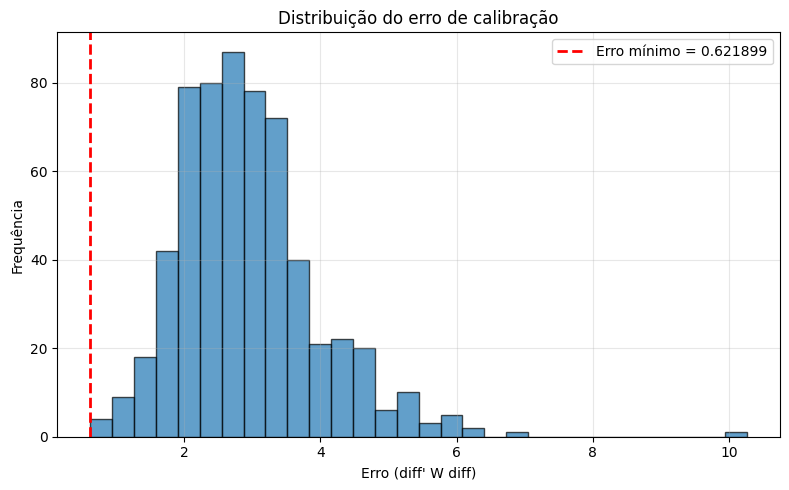

Erro mínimo: 0.6218985544851141

Parâmetros correspondentes:
a0      0.848228
b0      0.695407
c0      0.878559
beta    0.155958
p5      0.075485
erro    0.621899
Name: 527, dtype: float64


In [11]:
def analisar_erros(df_erros, col_erro="erro", bins=30):
    """
    Plota histograma dos erros e retorna:
      - erro mínimo
      - linha (parâmetros) correspondente ao erro mínimo
    """
    erros = df_erros[col_erro].to_numpy(dtype=float)

    # ---- Histograma ----
    plt.figure(figsize=(8,5))
    plt.hist(erros, bins=bins, edgecolor="black", alpha=0.7)
    plt.axvline(np.min(erros), color="red", linestyle="--", linewidth=2,
                label=f"Erro mínimo = {np.min(erros):.6f}")
    plt.title("Distribuição do erro de calibração")
    plt.xlabel("Erro (diff' W diff)")
    plt.ylabel("Frequência")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- Erro mínimo ----
    idx_min = np.argmin(erros)
    erro_min = erros[idx_min]

    linha_min = df_erros.iloc[idx_min]

    print("Erro mínimo:", erro_min)
    print("\nParâmetros correspondentes:")
    print(linha_min)

    return erro_min, linha_min


# ---- uso ----
erro_min, linha_min = analisar_erros(out_erros)

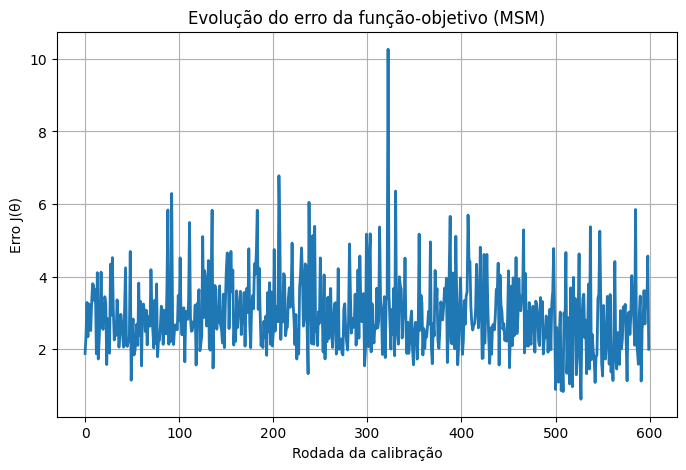

In [12]:
erros = out_erros["erro"]

# Plot
plt.figure(figsize=(8,5))
plt.plot(erros, linewidth=2)
plt.xlabel("Rodada da calibração")
plt.ylabel("Erro J(θ)")
plt.title("Evolução do erro da função-objetivo (MSM)")
plt.grid(True)
plt.show()

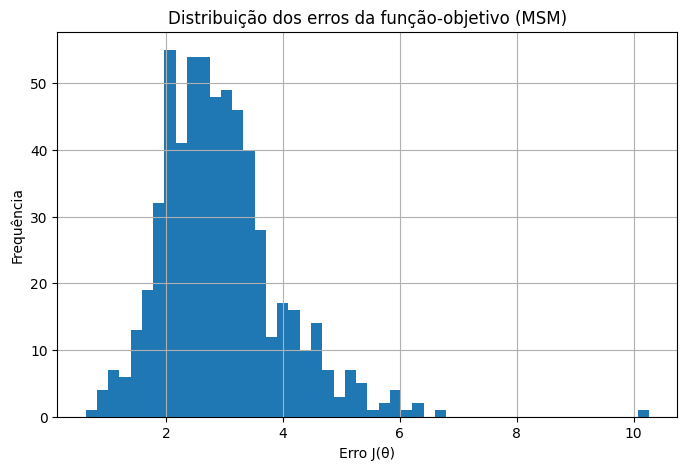

In [13]:
erros = out_erros["erro"]

plt.figure(figsize=(8,5))
plt.hist(erros, bins=50)
plt.xlabel("Erro J(θ)")
plt.ylabel("Frequência")
plt.title("Distribuição dos erros da função-objetivo (MSM)")
plt.grid(True)
plt.show()

In [17]:
erros.describe()

,erro
count,600.000000
mean,2.934816
std,1.020564
min,0.621899
25%,2.227460
50%,2.799219
75%,3.424842
max,10.264966


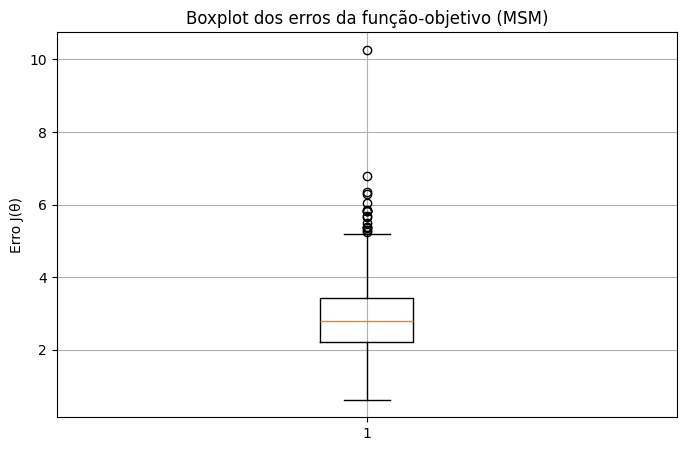

In [22]:
plt.figure(figsize=(8,5))
plt.boxplot(erros)
plt.ylabel("Erro J(θ)")
plt.title("Boxplot dos erros da função-objetivo (MSM)")
plt.grid(True)
plt.show()

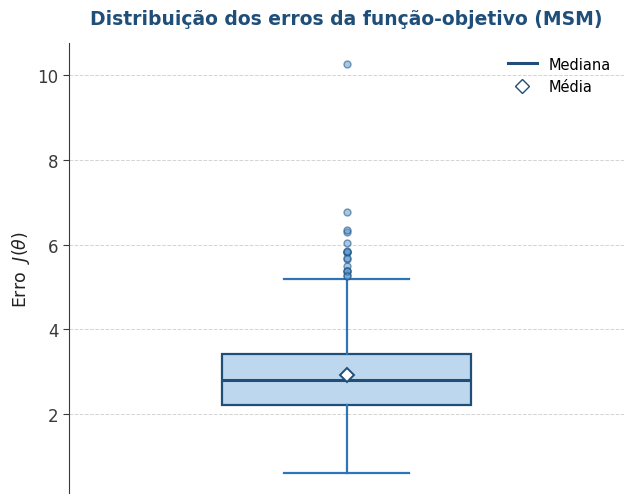

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# paleta azul
AZUL_ESCURO = "#1F4E79"   # mediana / bordas
AZUL_MEDIO  = "#2E75B6"   # whiskers / caps
AZUL_CLARO  = "#BDD7EE"   # preenchimento da caixa
AZUL_FLIER  = "#5B9BD5"   # outliers

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.edgecolor": "#3A3A3A",
})

fig, ax = plt.subplots(figsize=(6.5, 5.2))

bp = ax.boxplot(
    erros,
    widths=0.45,
    patch_artist=True,
    showmeans=True,
    boxprops=dict(facecolor=AZUL_CLARO, edgecolor=AZUL_ESCURO, linewidth=1.6),
    medianprops=dict(color=AZUL_ESCURO, linewidth=2.2),
    whiskerprops=dict(color=AZUL_MEDIO, linewidth=1.6),
    capprops=dict(color=AZUL_MEDIO, linewidth=1.6),
    flierprops=dict(marker="o", markersize=5,
                    markerfacecolor=AZUL_FLIER, markeredgecolor=AZUL_ESCURO, alpha=0.55),
    meanprops=dict(marker="D", markersize=7,
                   markerfacecolor="white", markeredgecolor=AZUL_ESCURO, markeredgewidth=1.4),
)

ax.set_title("Distribuição dos erros da função-objetivo (MSM)",
             fontsize=13.5, color=AZUL_ESCURO, fontweight="bold", pad=14)
ax.set_ylabel(r"Erro  $J(\theta)$", fontsize=12.5, color="#222222")
ax.set_xticks([])

ax.yaxis.grid(True, linestyle="--", linewidth=0.7, color="#C9C9C9", alpha=0.8)
ax.set_axisbelow(True)
for lado in ["top", "right", "bottom"]:
    ax.spines[lado].set_visible(False)
ax.tick_params(axis="y", colors="#3A3A3A", length=4)

legenda = [
    Line2D([0],[0], color=AZUL_ESCURO, lw=2.2, label="Mediana"),
    Line2D([0],[0], marker="D", color="none", markerfacecolor="white",
           markeredgecolor=AZUL_ESCURO, markersize=7, label="Média"),
]
ax.legend(handles=legenda, frameon=False, loc="upper right", fontsize=10.5)

fig.tight_layout()
fig.savefig("boxplot_erros_msm.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# Erro mínimo

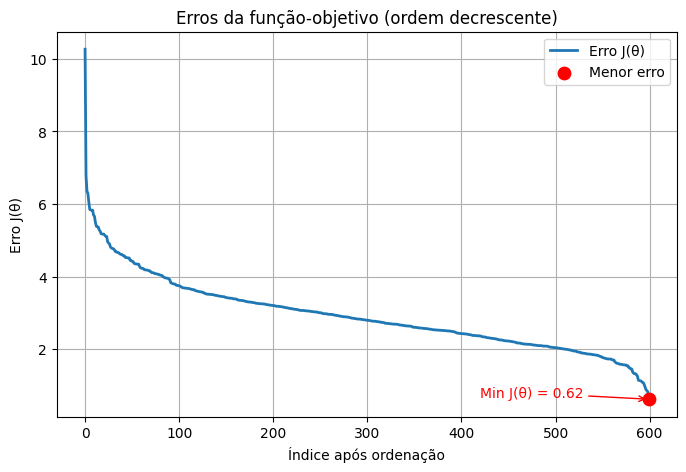

In [14]:
# Ordenar erros em ordem decrescente
erros_desc = out_erros["erro"].sort_values(ascending=False).reset_index(drop=True)

# Identificar o menor erro e sua posição
min_erro = erros_desc.min()
idx_min = erros_desc.idxmin()

# Plot
plt.figure(figsize=(8,5))
plt.plot(erros_desc, linewidth=2, label="Erro J(θ)")
plt.scatter(idx_min, min_erro, s=80, zorder=3, label="Menor erro", color='r')

# Anotação do ponto mínimo
plt.annotate(
    f"Min J(θ) = {min_erro:.2f}",
    xy=(idx_min, min_erro),
    xytext=(idx_min*0.7, min_erro*1.1),
    arrowprops=dict(arrowstyle="->", color = 'r'),
    color = 'r'
)

plt.xlabel("Índice após ordenação")
plt.ylabel("Erro J(θ)")
plt.title("Erros da função-objetivo (ordem decrescente)")
plt.legend()
plt.grid(True)
plt.show()

# Resultado da Calibração

In [15]:
parametros_sistema_calibrados = linha_min.to_numpy()[:-1]
parametros_sistema_calibrados

array([0.84822756, 0.69540723, 0.87855894, 0.15595803, 0.07548527])

In [16]:
pd.DataFrame(
    parametros_sistema_calibrados).T

,0,1,2,3,4
0,0.848228,0.695407,0.878559,0.155958,0.075485


In [ ]:
from google.colab import files

p = pd.DataFrame(
    parametros_sistema_calibrados).T

p.to_csv("parametros_sistema_calibrados.csv", index=False)
files.download("parametros_sistema_calibrados.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>